# 05 — Diagnostics

Part of a 5-notebook peptide-clustering + consensus-split exploration — see
`README_clustering.md` in this folder for the full picture and run order. Requires
notebooks 01-04 to have already run (reads `data/clustering/peptide_voters.parquet`,
`data/clustering/consensus_split.csv`, and `data/clustering/peptideclm_embeddings.npy`).

Four diagnostics, each its own section:
1. Linear vs. non-linear peptide counts per fold and in test.
2. Pairwise agreement (adjusted Rand index) between all four individual voter
   methods, with QMAP's coverage caveat annotated.
3. 2D UMAP visualization of fingerprint space and descriptor space, colored by each
   individual method's clusters and by each consensus partition.
4. An explicit check for peptides whose consensus cluster disagrees with their
   k-nearest-neighbors' consensus cluster under Tanimoto similarity.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

RDLogger.DisableLog("rdApp.*")


## Setup: load everything notebooks 01-04 produced

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root (no pyproject.toml found above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data"
CLUSTERING_DIR = DATA_DIR / "clustering"

voters_path = CLUSTERING_DIR / "peptide_voters.parquet"
split_path = CLUSTERING_DIR / "consensus_split.csv"
embeddings_path = CLUSTERING_DIR / "peptideclm_embeddings.npy"
for p in (voters_path, split_path, embeddings_path):
    if not p.exists():
        raise FileNotFoundError(f"{p} not found -- run notebooks 01-04 first.")

peptide_voters = pd.read_parquet(voters_path).reset_index(drop=True)
consensus_split = pd.read_csv(split_path)
peptideclm_embeddings = np.load(embeddings_path)

# consensus_split carries split/fold_id/consensus_* columns keyed by peptide_id;
# peptide_voters carries sequence/smiles/descriptors -- join them once here.
data = peptide_voters.merge(
    consensus_split[["peptide_id", "consensus_coassoc", "consensus_votegraph", "split", "fold_id", "community"]],
    on="peptide_id", how="left",
)
assert peptideclm_embeddings.shape[0] == len(data), "embeddings row count must match peptide_voters row order"
print(data.shape)
data.head()


(12371, 17)


,peptide_id,sequence,smiles,has_noncanonical,bond_type,is_linear,cluster_fingerprint,cluster_descriptor,qmap_input_sequence,qmap_scoreable,cluster_qmap,cluster_peptideclm,consensus_coassoc,consensus_votegraph,split,fold_id,community
0,10,LFIFFF,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,False,none,True,223.0,3.0,LFIFFF,True,7.0,4,13,0,train,1.0,13
1,11,RVKRVWPLVIRTVIAGYNLYRAIKKK,CC[C@H](C)[C@H](NC(=O)[C@H](C)NC(=O)[C@H](CCCN...,False,none,True,1.0,2.0,RVKRVWPLVIRTVIAGYNLYRAIKKK,True,53.0,0,25,3,train,4.0,25
2,12,RKRIHIGPGRAFYTT,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)...,False,none,True,8.0,2.0,RKRIHIGPGRAFYTT,True,457.0,3,11,5,train,2.0,11
3,13,RRXXRF,CC(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCN=C(N...,True,none,True,270.0,3.0,NaN,False,NaN,4,13,207,train,1.0,13
4,14,GIWDTIKSMGKVFAGKILQNL,CC[C@H](C)[C@H](NC(=O)CN)C(=O)N[C@@H](Cc1c[nH]...,False,none,True,3.0,2.0,GIWDTIKSMGKVFAGKILQNL,True,143.0,3,11,5,train,2.0,11


## 1. Linear vs. non-linear peptide counts per fold and in test

`is_linear` comes from `bond_type == "none"` (see notebooks 01-03's setup cells) --
a peptide with any annotated inter-residue bond (disulfide, head-to-tail, etc.)
counts as non-linear here.


In [3]:
data["fold_or_test"] = np.where(data["split"] == "test", "test", "fold_" + data["fold_id"].astype("Int64").astype(str))

linearity_table = pd.crosstab(data["fold_or_test"], data["is_linear"].map({True: "linear", False: "non-linear"}))
linearity_table["total"] = linearity_table.sum(axis=1)
linearity_table["% non-linear"] = (linearity_table["non-linear"] / linearity_table["total"] * 100).round(1)
linearity_table


is_linear,linear,non-linear,total,% non-linear
fold_or_test,,,,
fold_0,275,223,498,44.8
fold_1,1778,331,2109,15.7
fold_2,3068,150,3218,4.7
fold_3,1588,124,1712,7.2
fold_4,1399,735,2134,34.4
test,2202,498,2700,18.4


## 2. Pairwise agreement (adjusted Rand index) between the four individual voter methods

Restricted, for each pair, to peptides both methods actually scored (matters only
for pairs involving `cluster_qmap`, the one method with <100% coverage -- see the
coverage note printed with its row/column below).


In [4]:
VOTER_COLUMNS = ["cluster_fingerprint", "cluster_descriptor", "cluster_peptideclm", "cluster_qmap"]
coverage = {c: int(data[c].notna().sum()) for c in VOTER_COLUMNS}
print("coverage (peptides scored):", coverage,
      f"-- cluster_qmap is the only method below 100% ({coverage['cluster_qmap']}/{len(data)}, "
      f"see notebook 03 for the non-canonical/unresolved-residue coverage breakdown)")

ari_matrix = pd.DataFrame(index=VOTER_COLUMNS, columns=VOTER_COLUMNS, dtype=float)
for a in VOTER_COLUMNS:
    for b in VOTER_COLUMNS:
        both_scored = data[a].notna() & data[b].notna()
        ari_matrix.loc[a, b] = adjusted_rand_score(data.loc[both_scored, a], data.loc[both_scored, b])

ari_matrix.style.background_gradient(cmap="viridis", vmin=0, vmax=1).format("{:.3f}")


coverage (peptides scored): {'cluster_fingerprint': 12371, 'cluster_descriptor': 12371, 'cluster_peptideclm': 12371, 'cluster_qmap': 10888} -- cluster_qmap is the only method below 100% (10888/12371, see notebook 03 for the non-canonical/unresolved-residue coverage breakdown)


,cluster_fingerprint,cluster_descriptor,cluster_peptideclm,cluster_qmap
cluster_fingerprint,1.000,0.027,0.048,0.086
cluster_descriptor,0.027,1.000,0.124,0.049
cluster_peptideclm,0.048,0.124,1.000,0.048
cluster_qmap,0.086,0.049,0.048,1.000


## 3. 2D UMAP visualization

Fingerprint space (Morgan/ECFP bit vectors, Jaccard/Tanimoto metric) and descriptor
space (the 13 RDKit physicochemical descriptors, standardized, Euclidean metric),
each colored by all four individual methods' clusters and both consensus
partitions. Fingerprints are recomputed here (not persisted from notebook 01) to
keep this notebook self-contained.


In [5]:
_t0 = time.perf_counter()
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
mols = [Chem.MolFromSmiles(s) for s in data["smiles"]]
fingerprint_bits = np.zeros((len(mols), 2048), dtype=np.uint8)
for i, mol in enumerate(mols):
    DataStructs.ConvertToNumpyArray(morgan_gen.GetFingerprint(mol), fingerprint_bits[i])
print(f"fingerprints recomputed in {time.perf_counter() - _t0:.1f}s")

peptide_features = pd.read_csv(DATA_DIR / "peptide_features.csv")
descriptor_cols = [c for c in peptide_features.columns if c != "peptide_id"]
descriptor_df = data[["peptide_id"]].merge(peptide_features, on="peptide_id", how="left")
descriptor_scaled = StandardScaler().fit_transform(descriptor_df[descriptor_cols].values)

_t0 = time.perf_counter()
umap_fingerprint = umap.UMAP(n_components=2, random_state=42, metric="jaccard", n_jobs=1).fit_transform(fingerprint_bits)
print(f"UMAP (fingerprint space): {time.perf_counter() - _t0:.1f}s")

_t0 = time.perf_counter()
umap_descriptor = umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(descriptor_scaled)
print(f"UMAP (descriptor space): {time.perf_counter() - _t0:.1f}s")


fingerprints recomputed in 4.7s


/Users/lukajin/PycharmProjects/soamp/.venv/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


/Users/lukajin/PycharmProjects/soamp/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP (fingerprint space): 16.7s


UMAP (descriptor space): 6.3s


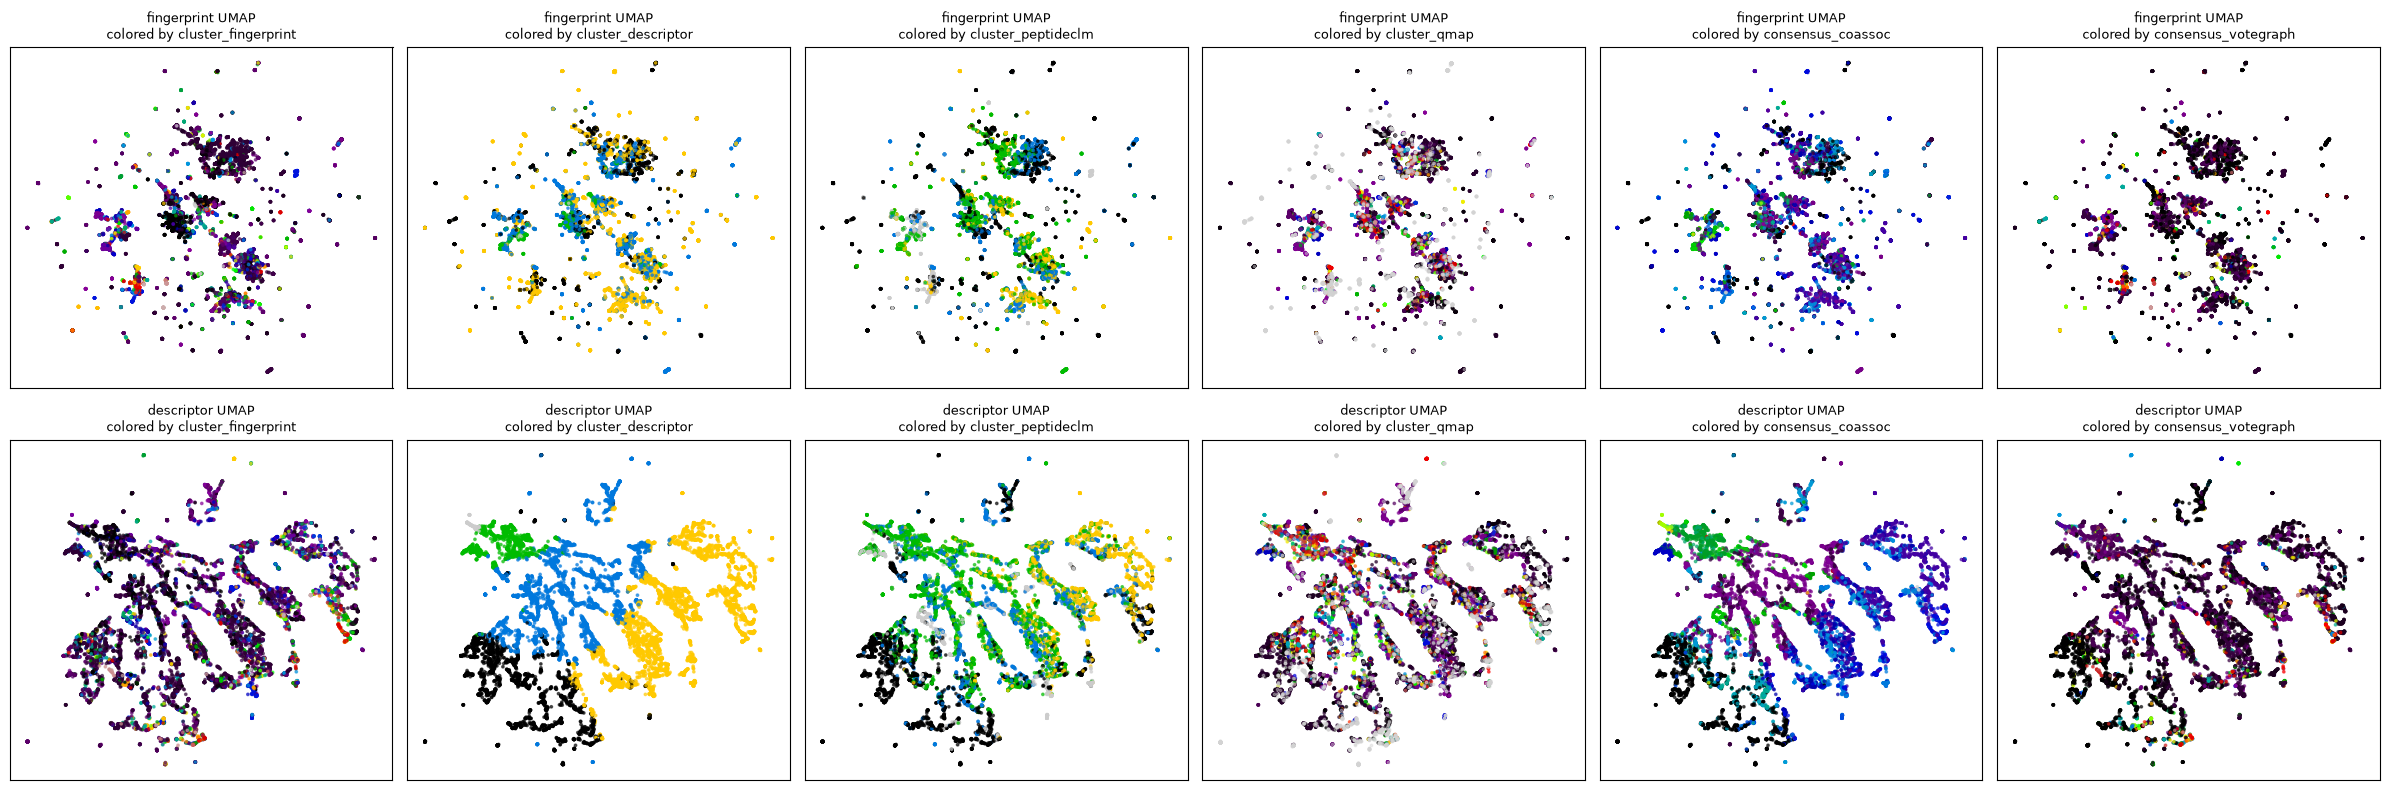

In [6]:
COLOR_BY_COLUMNS = ["cluster_fingerprint", "cluster_descriptor", "cluster_peptideclm", "cluster_qmap",
                     "consensus_coassoc", "consensus_votegraph"]


def scatter_colored(ax, coords, labels, title):
    labels = pd.Series(labels)
    is_na = labels.isna().values
    codes, _ = pd.factorize(labels)
    if (~is_na).any():
        ax.scatter(coords[~is_na, 0], coords[~is_na, 1], c=codes[~is_na], cmap="nipy_spectral", s=3, alpha=0.6)
    if is_na.any():
        ax.scatter(coords[is_na, 0], coords[is_na, 1], c="lightgray", s=3, alpha=0.4)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(2, len(COLOR_BY_COLUMNS), figsize=(4 * len(COLOR_BY_COLUMNS), 8))
for j, col in enumerate(COLOR_BY_COLUMNS):
    scatter_colored(axes[0, j], umap_fingerprint, data[col], f"fingerprint UMAP\ncolored by {col}")
    scatter_colored(axes[1, j], umap_descriptor, data[col], f"descriptor UMAP\ncolored by {col}")
plt.tight_layout()
plt.show()


## 4. kNN-vs-consensus agreement check

For each peptide, its k=10 nearest neighbors under Tanimoto similarity (fingerprint
space, method (a)'s metric) vote on the majority consensus cluster among
themselves; flag peptides whose *own* consensus cluster disagrees with that
majority. A high flagged rate would suggest the consensus partition is cutting
across peptides that are chemically very similar to each other -- worth checking
before committing to a split.


In [7]:
K_NEIGHBORS = 10
CONSENSUS_TO_CHECK = "consensus_coassoc"  # match notebook 04's CHOSEN_CONSENSUS, or set to the other one

_t0 = time.perf_counter()
fps = [morgan_gen.GetFingerprint(m) for m in mols]
n = len(fps)
knn_indices = np.zeros((n, K_NEIGHBORS), dtype=np.int32)
for i in range(n):
    sims = np.array(DataStructs.BulkTanimotoSimilarity(fps[i], fps))
    sims[i] = -1.0  # exclude self
    knn_indices[i] = np.argpartition(-sims, K_NEIGHBORS)[:K_NEIGHBORS]
print(f"kNN (Tanimoto, k={K_NEIGHBORS}) computed in {time.perf_counter() - _t0:.1f}s")

consensus_labels = data[CONSENSUS_TO_CHECK].to_numpy()
neighbor_majority = np.array([
    pd.Series(consensus_labels[knn_indices[i]]).mode().iloc[0] for i in range(n)
])
disagrees_with_neighbors = consensus_labels != neighbor_majority

print(f"{disagrees_with_neighbors.sum()}/{n} peptides ({disagrees_with_neighbors.mean():.1%}) are in a "
      f"different {CONSENSUS_TO_CHECK} cluster than the majority of their {K_NEIGHBORS} nearest "
      f"Tanimoto neighbors")

display_cols = ["peptide_id", "sequence", CONSENSUS_TO_CHECK]
data.loc[disagrees_with_neighbors, display_cols].assign(
    neighbor_majority_cluster=neighbor_majority[disagrees_with_neighbors]
).head(15)


kNN (Tanimoto, k=10) computed in 22.7s


4107/12371 peptides (33.2%) are in a different consensus_coassoc cluster than the majority of their 10 nearest Tanimoto neighbors


,peptide_id,sequence,consensus_coassoc,neighbor_majority_cluster
2,12,RKRIHIGPGRAFYTT,11,25
5,15,DSHAKRHHGYKRKFHEKHHSHRGY,10,4
6,16,ENREVPPGFTALIKTLRKCKII,25,11
7,36,NLVSGLIEARKYLEQLHRKLKNCKV,15,4
9,38,KAaaKWAaKaAK,1,13
11,52,KWLNALLHHGLNCAKGVLA,11,1
12,55,WLNALLHHGLNCAKGVLA,15,8
14,73,kGGGkWGGkGGk,9,13
15,77,KLllKWLlKlLK,8,13
22,87,XWKTLLKKVLKAAA,1,8
